# M1 · Logistic Regression

**Purpose:** the first real model. It is explainable and industry-standard, and it sets the bar that the tree models (M2-M4) must beat.

Logistic Regression learns one weight per feature, adds up `weight × value`, and turns the total into a probability with the sigmoid function:
`PD = 1 / (1 + exp(-(b0 + w1·x1 + ... + wn·xn)))`.

Two versions are trained:
- **A**: all features.
- **B**: without LendingClub's own risk view (`grade`, `sub_grade`, `int_rate`, `installment`). **B is the deployable model.**

Rules: fit on train, choose settings on validation, **test stays sealed**. Full plan: `IMPLEMENTATION_PLAN.md`.

## 1. Setup

In [1]:
import json, sys, time, platform
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "modeling").is_dir())
sys.path.insert(0, str(ROOT))
from src.modeling import evaluation as ev

RESULTS = ROOT / "models" / "M1_logistic_regression" / "results"
RESULTS.mkdir(parents=True, exist_ok=True)
print("Python", platform.python_version(), "| pandas", pd.__version__, "| scikit-learn", sklearn.__version__)

Python 3.13.9 | pandas 2.3.3 | scikit-learn 1.7.2


## 2. Load data and define versions A and B

In [2]:
X_train, y_train_frame = ev.load_split("train")
X_val, y_val_frame = ev.load_split("validation")
y_train = y_train_frame["target"].astype(int).to_numpy()
y_val = y_val_frame["target"].astype(int).to_numpy()
meta = json.loads(ev.METADATA_PATH.read_text(encoding="utf-8"))
expected = {r["split"]: r for r in meta["split_summary"]}
assert len(y_train) == expected["train"]["rows"] and len(y_val) == expected["validation"]["rows"]

lc_risk = meta["feature_groups"]["lc_risk_features"]
target_encoded = meta["feature_groups"]["target_encoded"]
print("fico_range_low vs fico_range_high correlation:",
      round(X_train["fico_range_low"].corr(X_train["fico_range_high"]), 6), "-> drop fico_range_high")

features = {
    "A": [c for c in X_train.columns if c != "fico_range_high"],
    "B": [c for c in X_train.columns if c != "fico_range_high" and c not in lc_risk],
}
for v, cols in features.items():
    print(f"Version {v}: {len(cols)} input features")
print(f"Version B removes {len(lc_risk)} LendingClub risk columns, e.g. {lc_risk[:3]} ... {lc_risk[-2:]}")
print(f"train {X_train.shape}, default rate {y_train.mean():.4f} | validation {X_val.shape}, default rate {y_val.mean():.4f}")

fico_range_low vs fico_range_high correlation: 1.0 -> drop fico_range_high
Version A: 189 input features
Version B: 147 input features
Version B removes 42 LendingClub risk columns, e.g. ['int_rate', 'installment', 'grade_A'] ... ['sub_grade_G2', 'sub_grade_infrequent_sklearn']
train (388124, 190), default rate 0.1724 | validation (162745, 190), default rate 0.2035


## 3. Which columns need a log transform?
Logistic Regression assumes a straight-line effect, so extremely skewed columns (a few huge values) are compressed with `log1p` first. The list is decided from **training data only**: continuous (non-binary), non-negative columns with skew above 2. Target-encoded columns are bounded rates, so they are only scaled.

In [3]:
binary_cols = [c for c in X_train.columns if X_train[c].nunique() <= 2]
continuous = [c for c in X_train.columns if c not in binary_cols and c not in target_encoded]
skew = X_train[continuous].skew()
log_candidates = sorted(c for c in continuous if skew[c] > 2 and X_train[c].min() >= 0)
print(f"binary: {len(binary_cols)} | continuous (excl. target-encoded): {len(continuous)} | log1p candidates: {len(log_candidates)}")
pd.DataFrame({"skew (train)": skew[log_candidates].round(1),
              "max": X_train[log_candidates].max().round(1)}).sort_values("skew (train)", ascending=False)

binary: 126 | continuous (excl. target-encoded): 61 | log1p candidates: 26


,skew (train),max
tot_coll_amt,612.3,9152545.0
total_rev_hi_lim,103.5,9999999.0
delinq_amnt,83.9,70076.0
tax_liens,45.3,63.0
num_tl_120dpd_2m,40.1,2.0
annual_inc,30.1,7500000.0
collections_12_mths_ex_med,29.7,20.0
num_tl_30dpd,23.6,4.0
revol_bal,21.2,2568995.0
acc_now_delinq,19.6,5.0


## 4. Model pipeline
`ColumnTransformer` [`log1p` + `StandardScaler` on skewed columns | `StandardScaler` on the rest] → `LogisticRegression` (L2 penalty, lbfgs solver). Everything is fitted on train only.

In [4]:
def build_pipeline(cols, prep, C, class_weight):
    if prep == "log+scale":
        logged = [c for c in log_candidates if c in cols]
        rest = [c for c in cols if c not in logged]
        transform = ColumnTransformer([
            ("log_scale", Pipeline([("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
                                    ("scale", StandardScaler())]), logged),
            ("scale", StandardScaler(), rest),
        ], verbose_feature_names_out=False)
    else:
        transform = ColumnTransformer([("scale", StandardScaler(), cols)], verbose_feature_names_out=False)
    model = LogisticRegression(C=C, class_weight=class_weight, penalty="l2", solver="lbfgs", max_iter=3000)
    return Pipeline([("prep", transform), ("logreg", model)])

build_pipeline(features["B"], "log+scale", 0.01, None)

,steps,"[('prep', ...), ('logreg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('log_scale', ...), ('scale', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


## 5. Hyper-parameter search on validation
2 preprocessing options × 5 values of `C` × 2 class weightings = 20 fits per version.
- **C** controls regularisation: small C = strong shrinkage of weights (simpler model).
- **class_weight="balanced"** up-weights defaults; it can help ranking but distorts probabilities.

In [5]:
grid = [(prep, C, cw) for prep in ("scale", "log+scale")
        for C in (0.0001, 0.001, 0.01, 0.1, 1.0) for cw in (None, "balanced")]
rows = []
for version, cols in features.items():
    Xt, Xv = X_train[cols], X_val[cols]
    for prep, C, cw in grid:
        start = time.time()
        pipe = build_pipeline(cols, prep, C, cw).fit(Xt, y_train)
        p = pipe.predict_proba(Xv)[:, 1]
        card = ev.report_card(y_val, p)
        rows.append({"version": version, "prep": prep, "C": C, "class_weight": str(cw),
                     "val_roc_auc": card["roc_auc"], "val_ks": card["ks"], "val_brier": card["brier"],
                     "val_log_loss": card["log_loss"], "val_mean_pd": card["mean_pd"],
                     "n_iter": int(pipe.named_steps["logreg"].n_iter_[0]), "seconds": round(time.time() - start, 1)})
tuning = pd.DataFrame(rows)
print(f"{len(tuning)} fits, total {tuning['seconds'].sum():.0f} s, max iterations used {tuning['n_iter'].max()} / 3000")
tuning.sort_values(["version", "val_roc_auc"], ascending=[True, False]).groupby("version").head(6).round(4)

40 fits, total 196 s, max iterations used 70 / 3000


,version,prep,C,class_weight,val_roc_auc,val_ks,val_brier,val_log_loss,val_mean_pd,n_iter,seconds
14,A,log+scale,0.010,None,0.7337,0.3409,0.1434,0.4480,0.1882,50,6.0
18,A,log+scale,1.000,None,0.7337,0.3408,0.1434,0.4479,0.1896,53,5.5
16,A,log+scale,0.100,None,0.7337,0.3409,0.1434,0.4479,0.1893,51,7.1
12,A,log+scale,0.001,None,0.7337,0.3415,0.1437,0.4488,0.1831,29,4.8
17,A,log+scale,0.100,balanced,0.7336,0.3407,0.2228,0.6343,0.4761,69,7.2
19,A,log+scale,1.000,balanced,0.7335,0.3404,0.2234,0.6358,0.4772,59,6.1
36,B,log+scale,0.100,None,0.7254,0.3264,0.1447,0.4527,0.1838,51,4.2
38,B,log+scale,1.000,None,0.7254,0.3266,0.1447,0.4527,0.1838,52,4.3
34,B,log+scale,0.010,None,0.7253,0.3267,0.1448,0.4527,0.1838,41,3.5
39,B,log+scale,1.000,balanced,0.7253,0.3266,0.2201,0.6303,0.4713,55,4.4


### Selection rule
Highest validation ROC-AUC. Among settings within **0.0005** of the best, prefer `class_weight=None` (honest probabilities), then the smallest `C` (simplest model).

In [6]:
chosen = {}
for version, part in tuning.groupby("version"):
    best = part["val_roc_auc"].max()
    near = part[part["val_roc_auc"] >= best - 0.0005].copy()
    near["cw_rank"] = (near["class_weight"] != "None").astype(int)
    pick = near.sort_values(["cw_rank", "C", "val_roc_auc"], ascending=[True, True, False]).iloc[0]
    chosen[version] = {"prep": pick["prep"], "C": float(pick["C"]),
                       "class_weight": None if pick["class_weight"] == "None" else pick["class_weight"]}
    print(f"Version {version}: best AUC {best:.4f}; chosen {chosen[version]} with AUC {pick['val_roc_auc']:.4f}")

effect = tuning.groupby(["version", "prep"])["val_roc_auc"].max().unstack().round(4)
print("\nBest validation AUC by preprocessing:"); print(effect)
cw_effect = tuning.groupby(["version", "class_weight"])[["val_roc_auc", "val_brier", "val_mean_pd"]].max().round(4)
print("\nEffect of class_weight (best per group):"); print(cw_effect)

Version A: best AUC 0.7337; chosen {'prep': 'log+scale', 'C': 0.0001, 'class_weight': None} with AUC 0.7335
Version B: best AUC 0.7254; chosen {'prep': 'log+scale', 'C': 0.001, 'class_weight': None} with AUC 0.7252

Best validation AUC by preprocessing:
prep     log+scale   scale
version                   
A           0.7337  0.7335
B           0.7254  0.7232

Effect of class_weight (best per group):
                      val_roc_auc  val_brier  val_mean_pd
version class_weight                                     
A       None               0.7337     0.1446       0.1898
        balanced           0.7336     0.2234       0.4773
B       None               0.7254     0.1460       0.1838
        balanced           0.7253     0.2214       0.4753


## 6. Fit the chosen models and score them

In [7]:
models, preds, cards = {}, {}, {}
for version, cfg in chosen.items():
    cols = features[version]
    pipe = build_pipeline(cols, cfg["prep"], cfg["C"], cfg["class_weight"]).fit(X_train[cols], y_train)
    models[version] = pipe
    preds[version] = {"train": pipe.predict_proba(X_train[cols])[:, 1],
                      "validation": pipe.predict_proba(X_val[cols])[:, 1]}
    cards[version] = {split: ev.report_card(y, preds[version][split])
                      for split, y in (("train", y_train), ("validation", y_val))}

board = pd.read_csv(ev.LEADERBOARD_PATH)
m0_val = board[(board.model == "M0") & (board.version == "A") & (board.split == "validation")].iloc[0]
compare = pd.DataFrame({
    "M0 (validation)": {k: m0_val[k] for k in ["roc_auc", "ks", "pr_auc", "brier", "log_loss", "mean_pd", "calibration_gap"]},
    **{f"M1-{v} ({s})": {k: cards[v][s][k] for k in ["roc_auc", "ks", "pr_auc", "brier", "log_loss", "mean_pd", "calibration_gap"]}
       for v in ("A", "B") for s in ("train", "validation")},
})
compare.astype(float).round(4)

,M0 (validation),M1-A (train),M1-A (validation),M1-B (train),M1-B (validation)
roc_auc,0.5000,0.7142,0.7335,0.7109,0.7252
ks,0.0000,0.3121,0.3421,0.3076,0.3262
pr_auc,0.2035,0.3387,0.4120,0.3362,0.4045
brier,0.1631,0.1303,0.1445,0.1306,0.1449
log_loss,0.5085,0.4173,0.4506,0.4185,0.4529
mean_pd,0.1724,0.1724,0.1773,0.1725,0.1837
calibration_gap,-0.0311,-0.0000,-0.0262,0.0000,-0.0198


## 7. Sanity checks: convergence, leakage flag, M0 bar

In [8]:
checks = []
for v in ("A", "B"):
    lr = models[v].named_steps["logreg"]
    val = cards[v]["validation"]
    checks += [
        (v, "solver converged", lr.n_iter_[0] < lr.max_iter, f"{lr.n_iter_[0]} / {lr.max_iter} iterations"),
        (v, "beats M0 ROC-AUC (0.500)", val["roc_auc"] > m0_val["roc_auc"], f"{val['roc_auc']:.4f}"),
        (v, "beats M0 Brier", val["brier"] < m0_val["brier"], f"{val['brier']:.4f} vs {m0_val['brier']:.4f}"),
        (v, "beats M0 log loss", val["log_loss"] < m0_val["log_loss"], f"{val['log_loss']:.4f} vs {m0_val['log_loss']:.4f}"),
        (v, "below 0.80 leakage flag", val["roc_auc"] < 0.80, f"{val['roc_auc']:.4f}"),
        (v, "train/validation AUC gap small (< 0.02)",
         abs(cards[v]["train"]["roc_auc"] - val["roc_auc"]) < 0.02,
         f"{cards[v]['train']['roc_auc']:.4f} vs {val['roc_auc']:.4f}"),
    ]
pd.DataFrame(checks, columns=["version", "check", "passed", "detail"])

,version,check,passed,detail
0,A,solver converged,True,15 / 3000 iterations
1,A,beats M0 ROC-AUC (0.500),True,0.7335
2,A,beats M0 Brier,True,0.1445 vs 0.1631
3,A,beats M0 log loss,True,0.4506 vs 0.5085
4,A,below 0.80 leakage flag,True,0.7335
5,A,train/validation AUC gap small (< 0.02),True,0.7142 vs 0.7335
6,B,solver converged,True,29 / 3000 iterations
7,B,beats M0 ROC-AUC (0.500),True,0.7252
8,B,beats M0 Brier,True,0.1449 vs 0.1631
9,B,beats M0 log loss,True,0.4529 vs 0.5085


## 8. What the model learned: coefficients
Features are standardised, so each weight is the change in **log-odds of default per 1 standard deviation** of that feature. `odds_ratio = exp(weight)`: 1.20 means about 20% higher odds of default per standard deviation.

*Caveat:* one-hot groups (e.g. all `addr_state_*` columns) share information, so read single dummy weights with care; continuous features are the most interpretable.

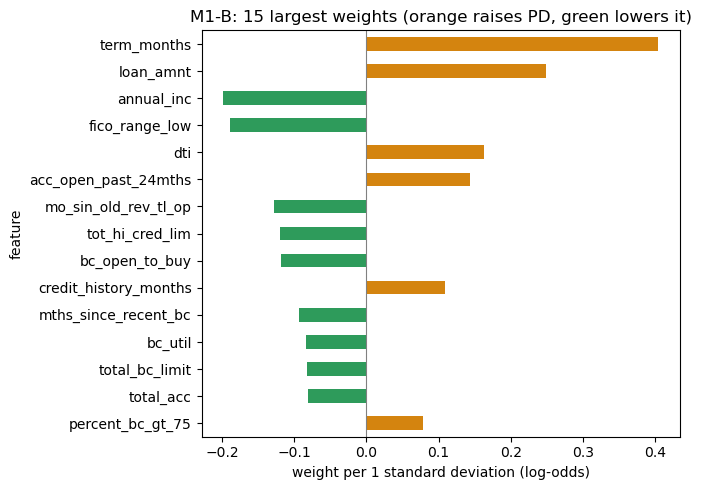

,feature,weight,odds_ratio
246,term_months,0.404,1.498
215,loan_amnt,0.248,1.282
190,annual_inc,-0.198,0.820
217,fico_range_low,-0.189,0.828
216,dti,0.163,1.178
225,acc_open_past_24mths,0.143,1.154
228,mo_sin_old_rev_tl_op,-0.128,0.880
210,tot_hi_cred_lim,-0.120,0.887
192,bc_open_to_buy,-0.118,0.889
245,credit_history_months,0.109,1.115


In [9]:
coef_tables = []
for v in ("A", "B"):
    pipe = models[v]
    names = pipe.named_steps["prep"].get_feature_names_out()
    w = pipe.named_steps["logreg"].coef_[0]
    coef_tables.append(pd.DataFrame({"version": v, "feature": names, "weight": w, "odds_ratio": np.exp(w)}))
coefs = pd.concat(coef_tables, ignore_index=True)
coefs["abs_weight"] = coefs["weight"].abs()
top_b = coefs[coefs.version == "B"].sort_values("abs_weight", ascending=False).head(15)
ax = top_b.iloc[::-1].plot.barh(x="feature", y="weight", legend=False, figsize=(7, 5),
                                color=["#d4840f" if w > 0 else "#2e9b5b" for w in top_b.iloc[::-1]["weight"]])
ax.axvline(0, color="grey", lw=0.8)
ax.set_title("M1-B: 15 largest weights (orange raises PD, green lowers it)")
ax.set_xlabel("weight per 1 standard deviation (log-odds)"); plt.tight_layout()
plt.savefig(RESULTS / "m1_coefficients.png", dpi=150); plt.show()
top_b[["feature", "weight", "odds_ratio"]].round(3)

In [10]:
def weight(v, f):
    s = coefs[(coefs.version == v) & (coefs.feature == f)]["weight"]
    return float(s.iloc[0]) if len(s) else float("nan")

intuition = [
    ("fico_range_low", "higher FICO -> lower risk", -1),
    ("dti", "higher debt-to-income -> higher risk", +1),
    ("term_months", "60-month term -> higher risk", +1),
    ("annual_inc", "higher income -> lower risk", -1),
    ("inq_last_6mths", "more recent credit inquiries -> higher risk", +1),
    ("int_rate", "higher interest rate -> higher risk (A only)", +1),
]
rows = []
for f, meaning, sign in intuition:
    for v in ("A", "B"):
        w = weight(v, f)
        if np.isnan(w):
            continue
        rows.append({"version": v, "feature": f, "expected": meaning, "weight": round(w, 4),
                     "matches_intuition": bool(np.sign(w) == sign)})
pd.DataFrame(rows)

,version,feature,expected,weight,matches_intuition
0,A,fico_range_low,higher FICO -> lower risk,-0.0728,True
1,B,fico_range_low,higher FICO -> lower risk,-0.1888,True
2,A,dti,higher debt-to-income -> higher risk,0.1163,True
3,B,dti,higher debt-to-income -> higher risk,0.1635,True
4,A,term_months,60-month term -> higher risk,0.2562,True
5,B,term_months,60-month term -> higher risk,0.4042,True
6,A,annual_inc,higher income -> lower risk,-0.1269,True
7,B,annual_inc,higher income -> lower risk,-0.1983,True
8,A,inq_last_6mths,more recent credit inquiries -> higher risk,0.0231,True
9,B,inq_last_6mths,more recent credit inquiries -> higher risk,0.0680,True


## 9. Calibration on validation
Predictions are grouped into 10 bins by predicted PD. A well-calibrated model sits on the diagonal (predicted = actual).

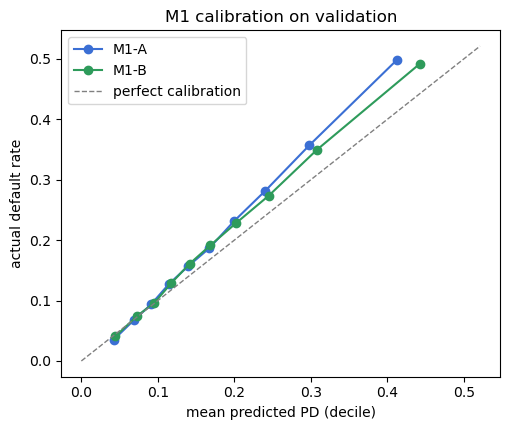

,predicted,actual,version
bin,,,
0,0.0425,0.0355,A
1,0.0686,0.0675,A
2,0.0912,0.0937,A
3,0.1143,0.1272,A
4,0.1394,0.1566,A
5,0.1671,0.1864,A
6,0.1996,0.2315,A
7,0.2405,0.2818,A
8,0.2980,0.3570,A


In [11]:
fig, ax = plt.subplots(figsize=(5.2, 4.4))
calib_rows = []
for v, color in (("A", "#3b6fd4"), ("B", "#2e9b5b")):
    frame = pd.DataFrame({"p": preds[v]["validation"], "y": y_val})
    frame["bin"] = pd.qcut(frame["p"], 10, labels=False, duplicates="drop")
    g = frame.groupby("bin").agg(predicted=("p", "mean"), actual=("y", "mean"))
    ax.plot(g["predicted"], g["actual"], marker="o", color=color, label=f"M1-{v}")
    calib_rows.append(g.assign(version=v))
lim = max(ax.get_xlim()[1], ax.get_ylim()[1])
ax.plot([0, lim], [0, lim], ls="--", color="grey", lw=1, label="perfect calibration")
ax.set_xlabel("mean predicted PD (decile)"); ax.set_ylabel("actual default rate")
ax.set_title("M1 calibration on validation"); ax.legend(); plt.tight_layout()
plt.savefig(RESULTS / "m1_calibration.png", dpi=150); plt.show()
pd.concat(calib_rows).round(4)

## 10. Approval-rate vs bad-rate curve (validation)
The lender approves the safest X% first. M0 was a flat line at 20.35%; a model with ranking power bends the curve down on the left.

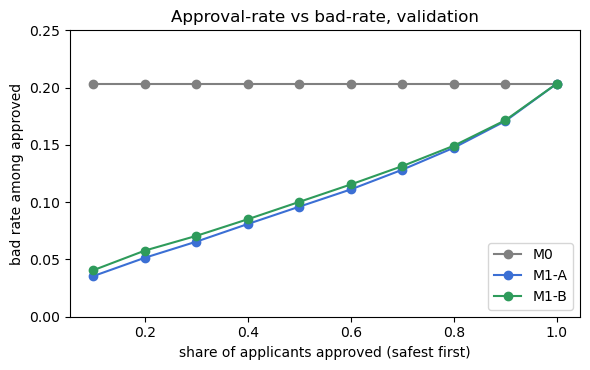

model,M0,M1-A,M1-B
approval_rate,,,
0.1,0.2035,0.0355,0.0406
0.2,0.2035,0.0515,0.0578
0.3,0.2035,0.0656,0.0706
0.4,0.2035,0.0810,0.0851
0.5,0.2035,0.0961,0.1003
0.6,0.2035,0.1111,0.1155
0.7,0.2035,0.1283,0.1315
0.8,0.2035,0.1475,0.1493
0.9,0.2035,0.1708,0.1715


In [12]:
curves = pd.concat([
    ev.approval_curve(y_val, np.full(len(y_val), m0_val["mean_pd"])).assign(model="M0"),
    ev.approval_curve(y_val, preds["A"]["validation"]).assign(model="M1-A"),
    ev.approval_curve(y_val, preds["B"]["validation"]).assign(model="M1-B"),
])
fig, ax = plt.subplots(figsize=(6, 3.8))
for name, color in (("M0", "grey"), ("M1-A", "#3b6fd4"), ("M1-B", "#2e9b5b")):
    part = curves[curves.model == name]
    ax.plot(part["approval_rate"], part["bad_rate_among_approved"], marker="o", color=color, label=name)
ax.set_xlabel("share of applicants approved (safest first)"); ax.set_ylabel("bad rate among approved")
ax.set_title("Approval-rate vs bad-rate, validation"); ax.legend(); ax.set_ylim(0, 0.25); plt.tight_layout()
plt.savefig(RESULTS / "m1_approval_curve.png", dpi=150); plt.show()
curves.pivot(index="approval_rate", columns="model", values="bad_rate_among_approved").round(4)

## 11. Segments: 36- vs 60-month loans

In [13]:
segments = pd.concat([
    ev.segment_report(y_val, preds[v]["validation"], X_val["term_months"], "term_months").assign(version=v, split="validation")
    for v in ("A", "B")
])
segments[["version", "term_months", "rows", "default_rate", "mean_pd", "calibration_gap", "roc_auc", "ks", "brier"]].round(4)

,version,term_months,rows,default_rate,mean_pd,calibration_gap,roc_auc,ks,brier
0,A,36.0,120790,0.1512,0.1403,-0.0110,0.6994,0.2911,0.1203
1,A,60.0,41955,0.3540,0.2841,-0.0699,0.6787,0.2624,0.2139
0,B,36.0,120790,0.1512,0.1419,-0.0094,0.6862,0.2751,0.1214
1,B,60.0,41955,0.3540,0.3043,-0.0497,0.6723,0.2487,0.2123


## 12. A vs B: how much do LendingClub's grades add?

In [14]:
a, b = cards["A"]["validation"], cards["B"]["validation"]
gap = {k: a[k] - b[k] for k in ("roc_auc", "ks", "pr_auc", "brier", "log_loss")}
print("Validation, A minus B:", {k: round(v, 4) for k, v in gap.items()})
print(f"\nWithout LendingClub's grade / sub_grade / int_rate / installment, the model keeps "
      f"{(b['roc_auc'] - 0.5) / (a['roc_auc'] - 0.5):.1%} of A's ranking power above a coin flip (ROC-AUC - 0.5).")

Validation, A minus B: {'roc_auc': 0.0083, 'ks': 0.0158, 'pr_auc': 0.0074, 'brier': -0.0004, 'log_loss': -0.0023}

Without LendingClub's grade / sub_grade / int_rate / installment, the model keeps 96.4% of A's ranking power above a coin flip (ROC-AUC - 0.5).


## 13. Save results

In [15]:
tuning.to_csv(RESULTS / "m1_tuning_results.csv", index=False)
coefs.drop(columns="abs_weight").to_csv(RESULTS / "m1_coefficients.csv", index=False)
segments.to_csv(RESULTS / "m1_segment_metrics.csv", index=False)
curves.to_csv(RESULTS / "m1_approval_curve.csv", index=False)
for v in ("A", "B"):
    joblib.dump(models[v], RESULTS / f"m1_{v}.joblib")
summary = {
    "model": "M1", "name": "Logistic Regression", "estimator": "sklearn.linear_model.LogisticRegression",
    "fixed_parameters": {"penalty": "l2", "solver": "lbfgs", "max_iter": 3000},
    "search_space": {"prep": ["scale", "log+scale"], "C": [0.0001, 0.001, 0.01, 0.1, 1.0],
                     "class_weight": [None, "balanced"]},
    "selection_rule": "max validation ROC-AUC; within 0.0005 prefer class_weight=None, then smallest C",
    "chosen": chosen, "n_features": {v: len(c) for v, c in features.items()},
    "dropped": {"all_versions": ["fico_range_high"], "version_B": lc_risk},
    "log1p_columns": log_candidates,
    "n_iter": {v: int(models[v].named_steps["logreg"].n_iter_[0]) for v in models},
    "environment": {"python": platform.python_version(), "pandas": pd.__version__, "scikit_learn": sklearn.__version__},
    "metrics": cards, "test_split": "sealed",
}
(RESULTS / "m1_metrics.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
for v in ("A", "B"):
    note = f"{chosen[v]['prep']}, C={chosen[v]['C']}, class_weight={chosen[v]['class_weight']}"
    for split in ("train", "validation"):
        board = ev.update_leaderboard("M1", v, split, cards[v][split], notes=note)
print("Saved:", sorted(p.name for p in RESULTS.iterdir()))
board.round(4)

Saved: ['m1_A.joblib', 'm1_B.joblib', 'm1_approval_curve.csv', 'm1_approval_curve.png', 'm1_calibration.png', 'm1_coefficients.csv', 'm1_coefficients.png', 'm1_metrics.json', 'm1_segment_metrics.csv', 'm1_tuning_results.csv']


,model,version,split,rows,default_rate,mean_pd,roc_auc,pr_auc,ks,brier,log_loss,calibration_gap,notes
0,M0,A,train,388124,0.1724,0.1724,0.5000,0.1724,0.0000,0.1427,0.4597,0.0000,constant PD = train default rate
1,M0,A,validation,162745,0.2035,0.1724,0.5000,0.2035,0.0000,0.1631,0.5085,-0.0311,constant PD = train default rate
2,M0,B,train,388124,0.1724,0.1724,0.5000,0.1724,0.0000,0.1427,0.4597,0.0000,constant PD = train default rate
3,M0,B,validation,162745,0.2035,0.1724,0.5000,0.2035,0.0000,0.1631,0.5085,-0.0311,constant PD = train default rate
4,M1,A,train,388124,0.1724,0.1724,0.7142,0.3387,0.3121,0.1303,0.4173,-0.0000,"log+scale, C=0.0001, class_weight=None"
5,M1,A,validation,162745,0.2035,0.1773,0.7335,0.4120,0.3421,0.1445,0.4506,-0.0262,"log+scale, C=0.0001, class_weight=None"
6,M1,B,train,388124,0.1724,0.1725,0.7109,0.3362,0.3076,0.1306,0.4185,0.0000,"log+scale, C=0.001, class_weight=None"
7,M1,B,validation,162745,0.2035,0.1837,0.7252,0.4045,0.3262,0.1449,0.4529,-0.0198,"log+scale, C=0.001, class_weight=None"


## 14. Conclusion: the bar M2 must clear

In [16]:
for v in ("A", "B"):
    c = cards[v]["validation"]
    print(f"M1-{v} validation: ROC-AUC {c['roc_auc']:.4f} | KS {c['ks']:.4f} | PR-AUC {c['pr_auc']:.4f} | "
          f"Brier {c['brier']:.4f} | log loss {c['log_loss']:.4f} | mean PD {c['mean_pd']:.4f} vs actual {c['default_rate']:.4f}")
print("\nM2 (Random Forest) is worth keeping only if it clearly beats these, especially for version B (the deployable one).")

M1-A validation: ROC-AUC 0.7335 | KS 0.3421 | PR-AUC 0.4120 | Brier 0.1445 | log loss 0.4506 | mean PD 0.1773 vs actual 0.2035
M1-B validation: ROC-AUC 0.7252 | KS 0.3262 | PR-AUC 0.4045 | Brier 0.1449 | log loss 0.4529 | mean PD 0.1837 vs actual 0.2035

M2 (Random Forest) is worth keeping only if it clearly beats these, especially for version B (the deployable one).
